# Import

In [667]:
import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rbf_main import RBF, one_hot, set_seed

# Cas de tests, rendu 3

## Classification

### Linear Simple :

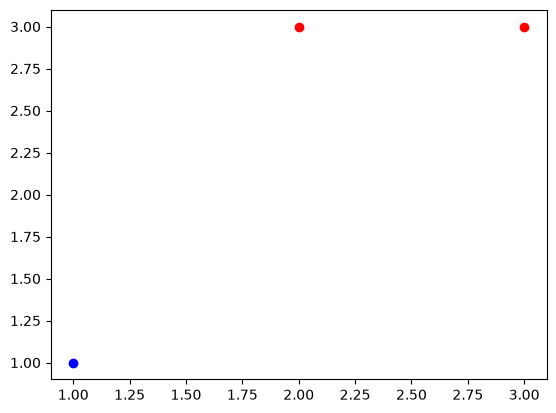

<Figure size 640x480 with 0 Axes>

In [649]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
'''
Y = np.array([
      1,
      -1,
      -1
])
'''
Y = np.array([
    [1, 0],
    [0, 1],
    [0, 1]
])


plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

#### Model

Loss finale : 0.006236


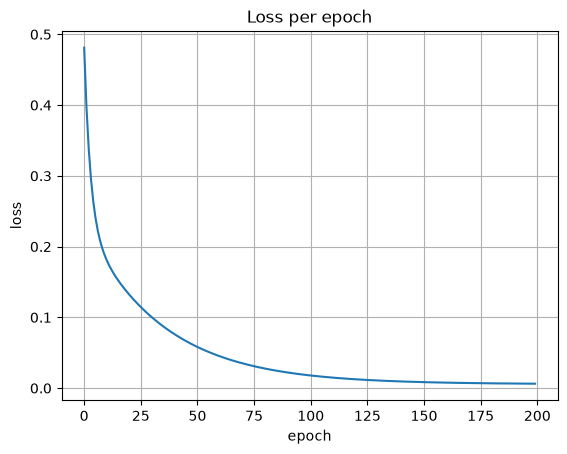

In [650]:
'''
nombre_de_centre = 2
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")
'''

model = RBF(nb_centres=2, gamma=0.1)
model.init_classif(X, 2)

losses = []
for epoch in range(200):
    losses.append(model.train_epoch(Y, learning_rate=0.05))
print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss per epoch"); plt.grid(True); plt.show(); plt.close()

#### Plot

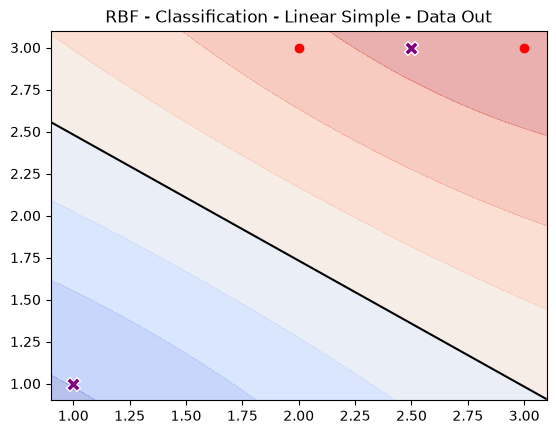

<Figure size 640x480 with 0 Axes>

In [651]:
xx, yy = np.meshgrid(np.linspace(0.9, 3.1, 300), np.linspace(0.9, 3.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_armax = model.predict_scores(grid).argmax(axis=1).reshape(xx.shape)
score_c = model.predict_scores(grid)   
diff = (score_c[:, 1] - score_c[:, 0]).reshape(xx.shape)

plt.contourf(xx, yy, diff, alpha=0.4, cmap="coolwarm")
plt.contour(xx, yy, diff, levels=[0], colors='black', linewidths=1.5)
classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.title("Frontière de décision - RBF")


# centres du k-means
plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=100, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - Linear Simple - Data Out")
plt.show()
plt.clf()

### Linear Multiple :

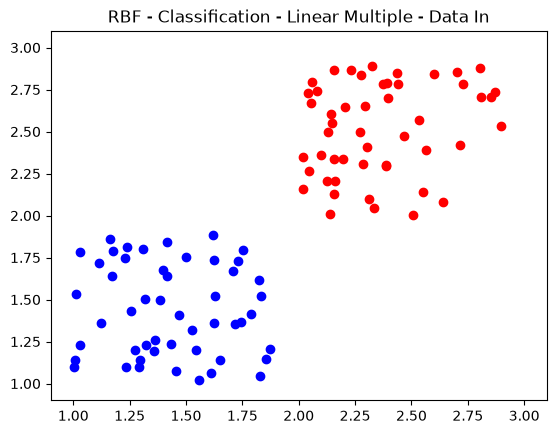

<Figure size 640x480 with 0 Axes>

In [652]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([
    np.tile([1, 0], (50, 1)),
    np.tile([0, 1], (50, 1))
])

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')

plt.xlim(0.9, 3.1)
plt.ylim(0.9, 3.1)

plt.title("RBF - Classification - Linear Multiple - Data In")
plt.show()
plt.clf()

#### Model

Loss finale : 0.018168


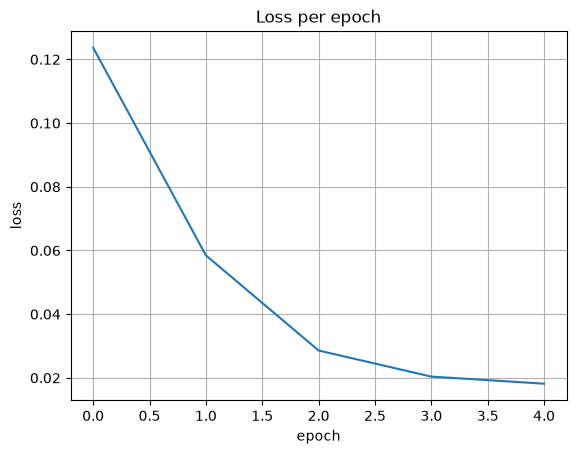

In [653]:
'''
nombre_de_centre = 2
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")
'''

model = RBF(nb_centres=2, gamma=0.5)
model.init_classif(X, 2)

losses = []
for epoch in range(5):
    losses.append(model.train_epoch(Y, learning_rate=0.05))
print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss per epoch"); plt.grid(True); plt.show(); plt.close()

#### Plot

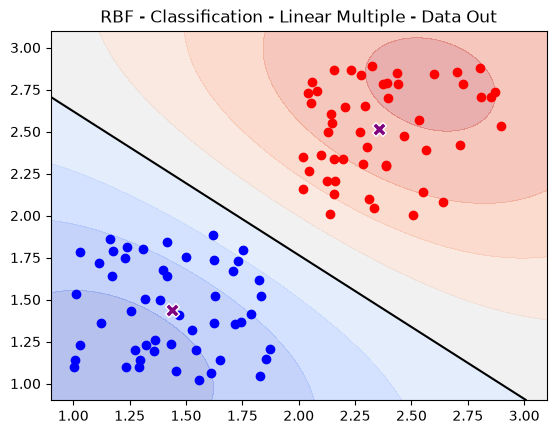

<Figure size 640x480 with 0 Axes>

In [654]:
xx, yy = np.meshgrid(np.linspace(0.9, 3.1, 300), np.linspace(0.9, 3.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_armax = model.predict_scores(grid).argmax(axis=1).reshape(xx.shape)
score_c = model.predict_scores(grid)   
diff = (score_c[:, 1] - score_c[:, 0]).reshape(xx.shape)

plt.contourf(xx, yy, diff, alpha=0.4, cmap="coolwarm")
plt.contour(xx, yy, diff, levels=[0], colors='black', linewidths=1.5)
classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.title("Frontière de décision - RBF")


# centres du k-means
plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=100, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - Linear Multiple - Data Out")
plt.show()
plt.clf()

### XOR :

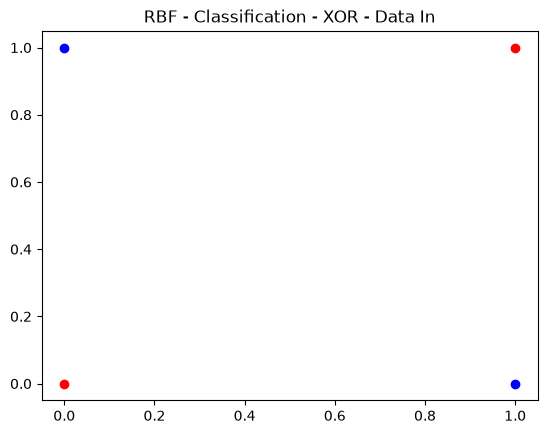

<Figure size 640x480 with 0 Axes>

In [655]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([
    [1, 0],
    [1, 0],
    [0, 1],
    [0, 1]
], dtype=float)

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')

plt.title("RBF - Classification - XOR - Data In")
plt.show()
plt.clf()

#### Model

Loss finale : 0.009933


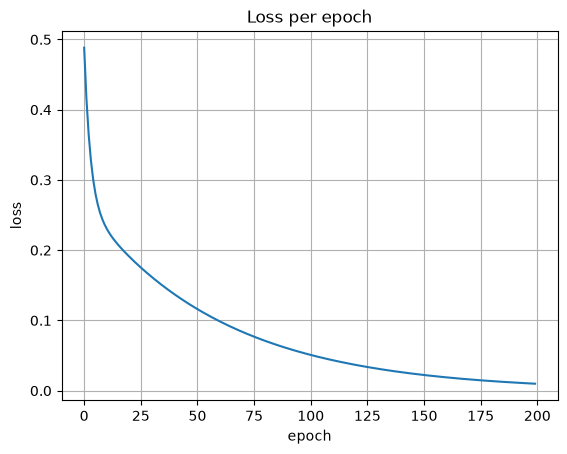

In [656]:
'''
#set_seed(14) # cette seed passe a peu pres avec k_centre < nb_points (3 centres pour les 4 points du xor)
nombre_de_centre = 4
model = RBF(nb_centres=nombre_de_centre, gamma=0.05)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")
'''

model = RBF(nb_centres=4, gamma=1)
model.init_classif(X, 2)

losses = []
for epoch in range(200):
    losses.append(model.train_epoch(Y, learning_rate=.05))
print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss per epoch"); plt.grid(True); plt.show(); plt.close()

#### Plot

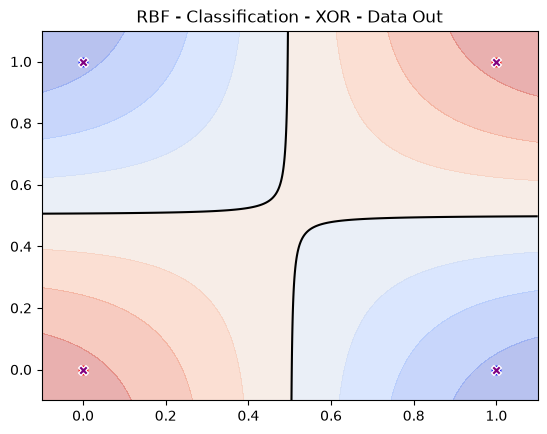

<Figure size 640x480 with 0 Axes>

In [657]:
xx, yy = np.meshgrid(np.linspace(-0.1, 1.1, 300), np.linspace(-0.1, 1.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_armax = model.predict_scores(grid).argmax(axis=1).reshape(xx.shape)
score_c = model.predict_scores(grid)   
diff = (score_c[:, 1] - score_c[:, 0]).reshape(xx.shape)

plt.contourf(xx, yy, diff, alpha=0.4, cmap="coolwarm")
plt.contour(xx, yy, diff, levels=[0], colors='black', linewidths=1.5)
classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.title("Frontière de décision - RBF")


# centres du k-means
plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=50, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - XOR - Data Out")
plt.show()
plt.clf()

### Cross :

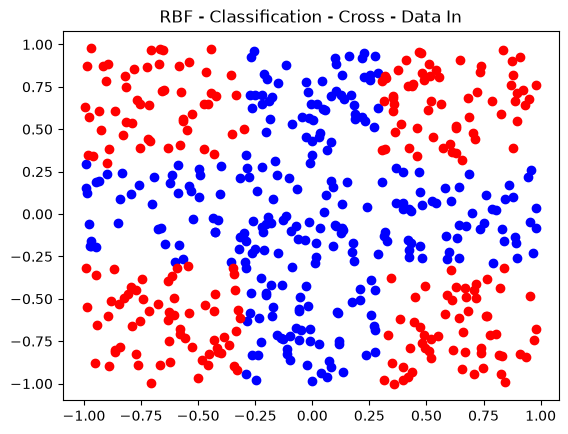

<Figure size 640x480 with 0 Axes>

In [658]:
X = np.random.random((500, 2)) * 2.0 - 1.0
y_label = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
Y = one_hot(np.where(y_label == 1, 0, 1), 2)

classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')

plt.title("RBF - Classification - Cross - Data In")
plt.show()
plt.clf()

#### Model

In [659]:
'''
ls_err = []
ls_nb_centre = np.arange(20, 150)
for centre in ls_nb_centre:
    model = RBF(nb_centres=centre, gamma=10.0)
    mse = model.train(X, Y)
    ls_err.append(mse)

ls_err = np.array(ls_err)

best_idx = np.argmin(ls_err)
best_centre = ls_nb_centre[best_idx]
best_mse = ls_err[best_idx]

# choix nb centre
plt.figure(figsize=(10,5))
plt.plot(ls_nb_centre, ls_err, label="MSE")

plt.axvline(best_centre, color='r', linestyle='--', label=f"best = {best_centre}")
plt.scatter([best_centre], [best_mse], color='red')

plt.xlabel("Nombre de centres")
plt.ylabel("MSE")
plt.title("Erreur en fonction du nombre de centres")
plt.grid(True)
plt.legend()

plt.show()
'''


'\nls_err = []\nls_nb_centre = np.arange(20, 150)\nfor centre in ls_nb_centre:\n    model = RBF(nb_centres=centre, gamma=10.0)\n    mse = model.train(X, Y)\n    ls_err.append(mse)\n\nls_err = np.array(ls_err)\n\nbest_idx = np.argmin(ls_err)\nbest_centre = ls_nb_centre[best_idx]\nbest_mse = ls_err[best_idx]\n\n# choix nb centre\nplt.figure(figsize=(10,5))\nplt.plot(ls_nb_centre, ls_err, label="MSE")\n\nplt.axvline(best_centre, color=\'r\', linestyle=\'--\', label=f"best = {best_centre}")\nplt.scatter([best_centre], [best_mse], color=\'red\')\n\nplt.xlabel("Nombre de centres")\nplt.ylabel("MSE")\nplt.title("Erreur en fonction du nombre de centres")\nplt.grid(True)\nplt.legend()\n\nplt.show()\n'

Loss finale : 0.046007


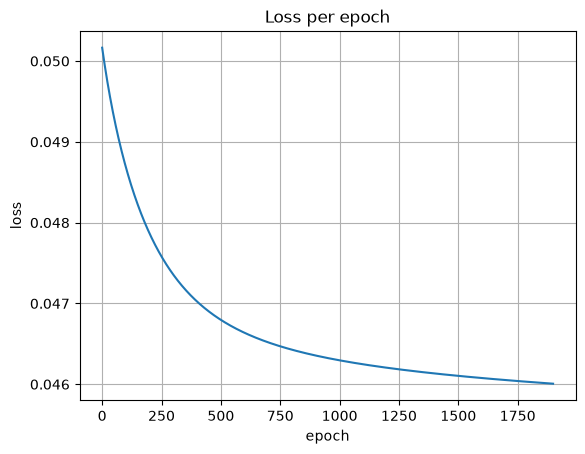

In [660]:

'''
model = RBF(nb_centres=best_centre, gamma=5.0)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")
'''

model = RBF(nb_centres=100, gamma=5)
model.init_classif(X, 2)

losses = []
for epoch in range(2000):
    losses.append(model.train_epoch(Y, learning_rate=.05))
print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses[100:]); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss per epoch"); plt.grid(True); plt.show(); plt.close()

#### Plot

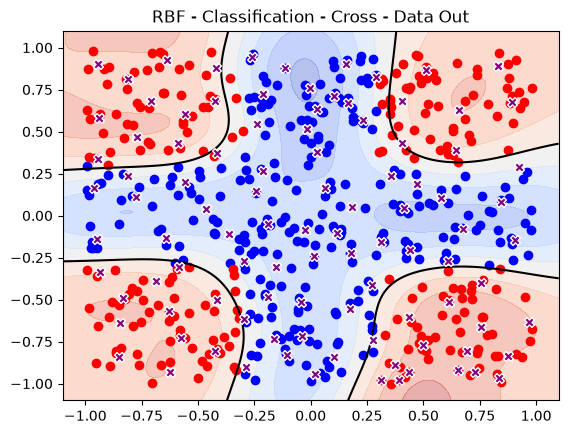

<Figure size 640x480 with 0 Axes>

In [661]:
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_c = model.predict_scores(grid)
diff = (score_c[:, 1] - score_c[:, 0]).reshape(xx.shape)

plt.contourf(xx, yy, diff, alpha=0.4, cmap="coolwarm")
plt.contour(xx, yy, diff, levels=[0], colors='black', linewidths=1.5)

classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.title("Frontière de décision - RBF")

# centres du k-means
plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=50, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - Cross - Data Out")
plt.show()
plt.clf()

### Multi Linear 3 CLasses :

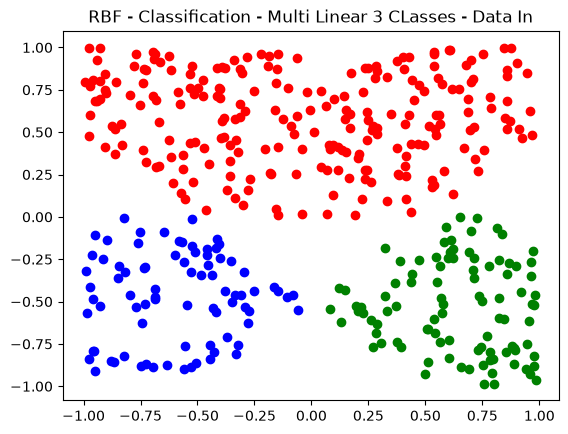

<Figure size 640x480 with 0 Axes>

In [662]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [0, 0, 0] for p in X])

mask = [not np.all(arr == [0, 0, 0]) for arr in Y]
X = X[mask]
Y = Y[mask]

classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.scatter(X[classes==2,0], X[classes==2,1], color='green')

plt.title("RBF - Classification - Multi Linear 3 CLasses - Data In")
plt.show()
plt.clf()

#### Model

In [663]:
nombre_de_centre = 15
model = RBF(nb_centres=nombre_de_centre, gamma=5.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.014869


#### Plot

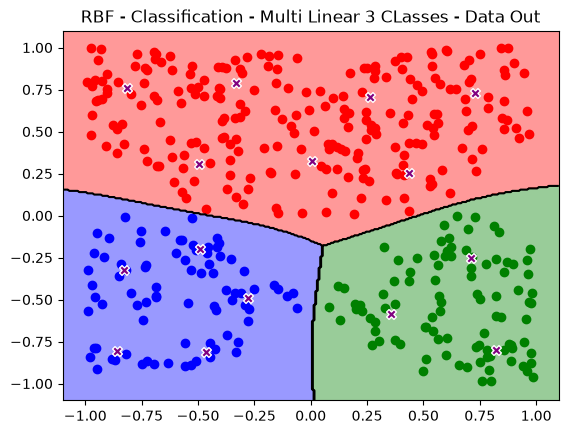

<Figure size 640x480 with 0 Axes>

In [664]:
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_c = model.predict_scores(grid)
pred = score_c.argmax(axis=1).reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.4, cmap=ListedColormap(['blue', 'red', 'green']))
plt.contour(xx, yy, pred, levels=[0.5, 1.5], colors='black', linewidths=1.5)

classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.scatter(X[classes==2,0], X[classes==2,1], color='green')
plt.title("Frontière de décision - RBF (3 classes)")

plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=50, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - Multi Linear 3 CLasses - Data Out")
plt.show()
plt.clf()

### Multi Cross :

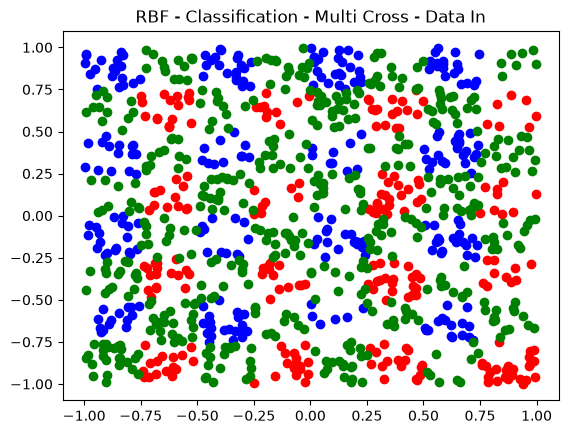

<Figure size 640x480 with 0 Axes>

In [665]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')

plt.title("RBF - Classification - Multi Cross - Data In")
plt.show()
plt.clf()

#### Model

100%|██████████| 200000/200000 [12:46<00:00, 261.01it/s]


Loss finale : 0.278233


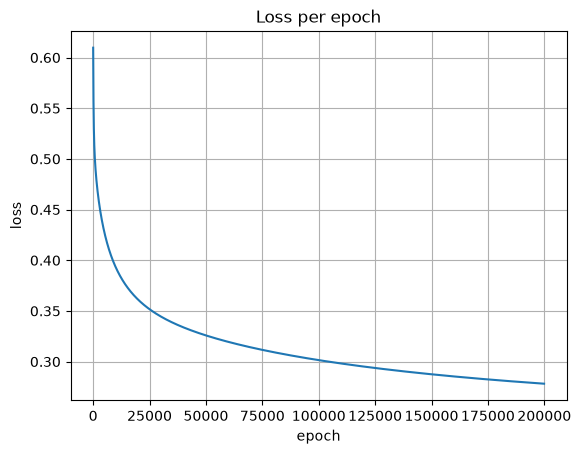

In [669]:
'''
nombre_de_centre = 50
model = RBF(nb_centres=nombre_de_centre, gamma=10)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")
'''

model = RBF(nb_centres=150, gamma=10)
model.init_classif(X, 3)

losses = []
for epoch in tqdm.tqdm(range(200000)):
    losses.append(model.train_epoch(Y, learning_rate=.05))
print(f"Loss finale : {losses[-1]:.6f}")

plt.plot(losses[100:]); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss per epoch"); plt.grid(True); plt.show(); plt.close()

#### Plot

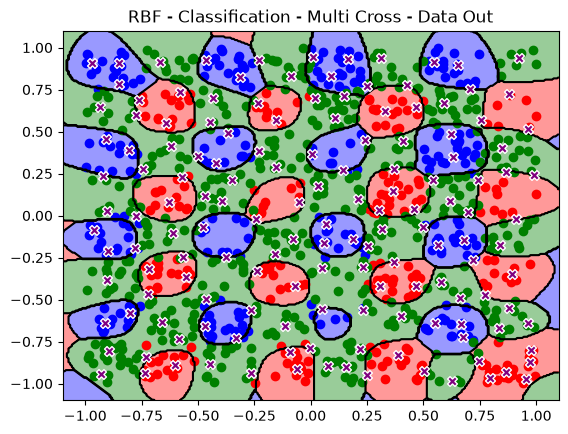

<Figure size 640x480 with 0 Axes>

In [670]:
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 300), np.linspace(-1.1, 1.1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

score_c = model.predict_scores(grid)
pred = score_c.argmax(axis=1).reshape(xx.shape)

plt.contourf(xx, yy, pred, alpha=0.4, cmap=ListedColormap(['blue', 'red', 'green']))
plt.contour(xx, yy, pred, levels=[0.5, 1.5], colors='black', linewidths=1.5)

classes = Y.argmax(axis=1)
plt.scatter(X[classes==0,0], X[classes==0,1], color='blue')
plt.scatter(X[classes==1,0], X[classes==1,1], color='red')
plt.scatter(X[classes==2,0], X[classes==2,1], color='green')
plt.title("Frontière de décision - RBF (3 classes)")

plt.scatter(model.centres[:,0], model.centres[:,1],
            marker="X", c="purple", edgecolor="white", s=50, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("RBF - Classification - Multi Cross - Data Out")
plt.show()
plt.clf()

## Regression

### Linear Simple 2D :

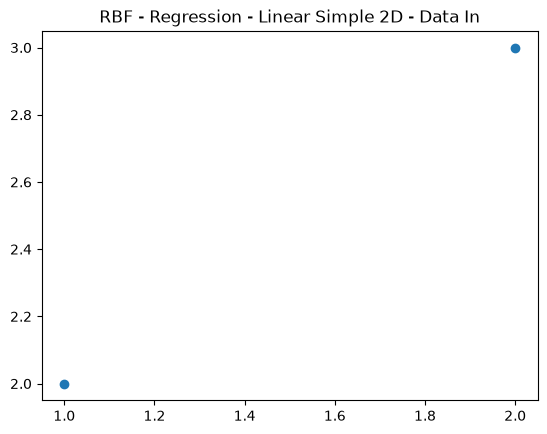

<Figure size 640x480 with 0 Axes>

In [ ]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      [2],
      [3]
])

plt.scatter(X,Y)

plt.title("RBF - Regression - Linear Simple 2D - Data In")
plt.show()
plt.clf()

#### Model

In [ ]:
nombre_de_centre = 2
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.000000


#### Plot

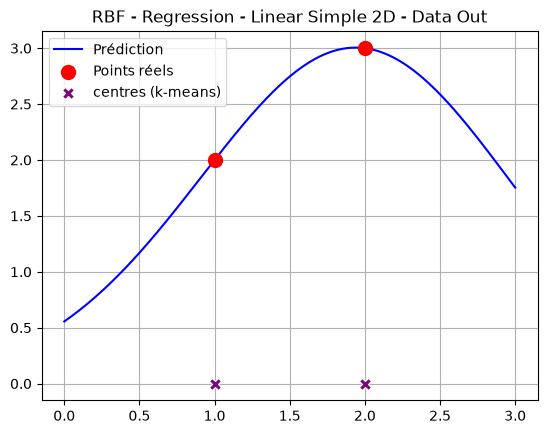

<Figure size 640x480 with 0 Axes>

In [ ]:
x_range = np.linspace(0, 3, 300).reshape(-1, 1)
y_pred = model.predict_scores(x_range)[:, 0]

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')

# centres du k-means
plt.scatter(model.centres[:, 0], np.zeros(len(model.centres)),
            marker="X", c="purple", edgecolor="white", s=80, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("Régression — Linear Simple 2D")
plt.legend()
plt.grid(True)

plt.title("RBF - Regression - Linear Simple 2D - Data Out")
plt.show()
plt.clf()

### Non Linear Simple 2D :

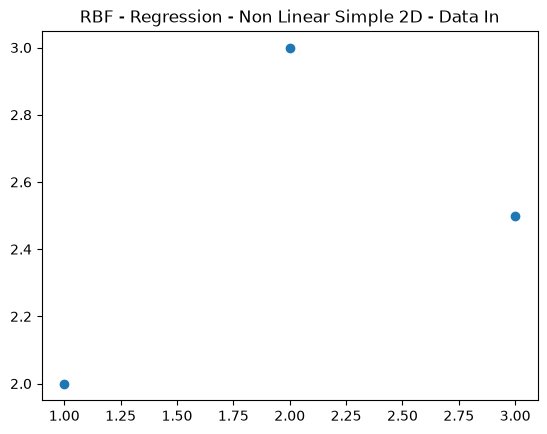

<Figure size 640x480 with 0 Axes>

In [ ]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      [2],
      [3],
      [2.5]
])

plt.scatter(X,Y)

plt.title("RBF - Regression - Non Linear Simple 2D - Data In")
plt.show()
plt.clf()

#### Model

In [ ]:
nombre_de_centre = 2
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.002727


#### Plot

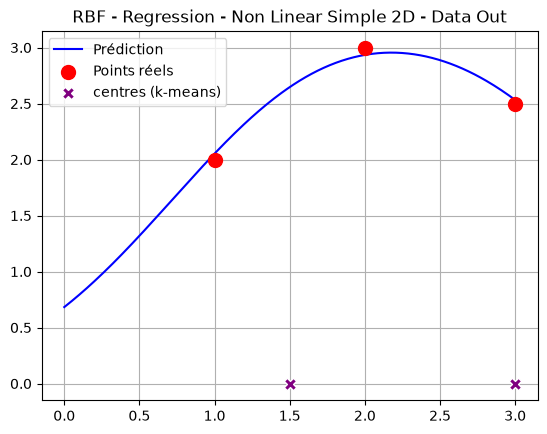

<Figure size 640x480 with 0 Axes>

In [ ]:
x_range = np.linspace(0, 3, 300).reshape(-1, 1)
y_pred = model.predict_scores(x_range)[:, 0]

plt.plot(x_range, y_pred, color='blue', label='Prédiction')
plt.scatter(X, Y, color='red', s=100, zorder=5, label='Points réels')

# centres du k-means
plt.scatter(model.centres[:, 0], np.zeros(len(model.centres)),
            marker="X", c="purple", edgecolor="white", s=80, linewidths=1,
            label="centres (k-means)", zorder=6)

plt.title("Régression — Linear Simple 2D")
plt.legend()
plt.grid(True)

plt.title("RBF - Regression - Non Linear Simple 2D - Data Out")
plt.show()
plt.clf()

### Linear Simple 3D :

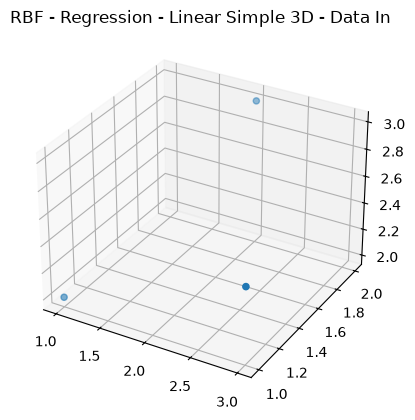

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      [2],
      [3],
      [2.5]
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y[:,0])

plt.title("RBF - Regression - Linear Simple 3D - Data In")
plt.show()

#### Model

In [ ]:
nombre_de_centre = 3
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.000000


#### Plot

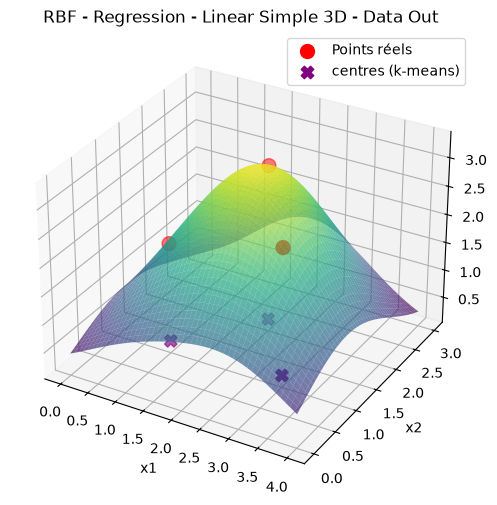

In [ ]:
xx, yy = np.meshgrid(np.linspace(0, 4, 100), np.linspace(0, 3, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_scores(grid)[:, 0].reshape(xx.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.7)

ax.scatter(X[:,0], X[:,1], Y[:,0], color='red', s=100, label='Points réels')

# centres du k-means
ax.scatter(model.centres[:,0], model.centres[:,1],
           np.full(len(model.centres), Z.min()),
           marker="X", c="purple", s=80, label='centres (k-means)')

ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.legend()

plt.title("RBF - Regression - Linear Simple 3D - Data Out")
plt.show()

### Linear Tricky 3D :

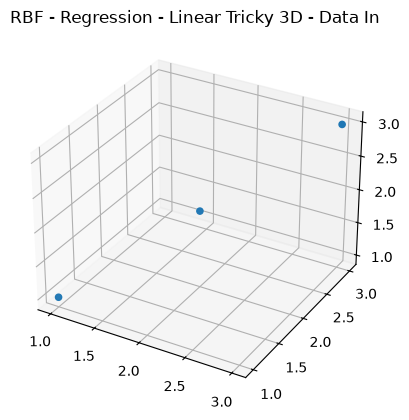

In [ ]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      [1],
      [2],
      [3]
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], Y[:,0])

plt.title("RBF - Regression - Linear Tricky 3D - Data In")
plt.show()

#### Model

In [ ]:
nombre_de_centre = 3
model = RBF(nb_centres=nombre_de_centre, gamma=0.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.000000


#### Plot

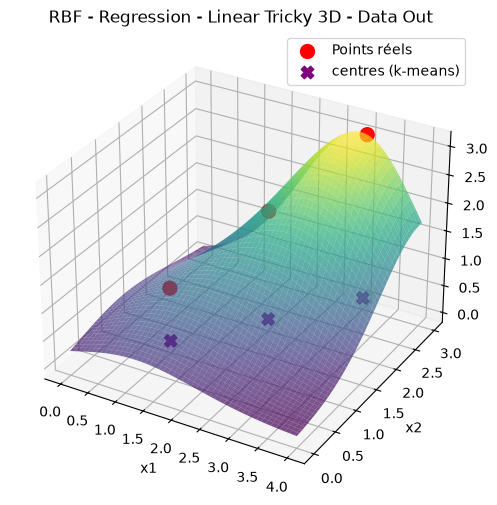

<Figure size 640x480 with 0 Axes>

In [ ]:
xx, yy = np.meshgrid(np.linspace(0, 4, 100), np.linspace(0, 3, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_scores(grid)[:, 0].reshape(xx.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.7)

ax.scatter(X[:,0], X[:,1], Y[:,0], color='red', s=100, label='Points réels')

# centres du k-means
ax.scatter(model.centres[:,0], model.centres[:,1],
           np.full(len(model.centres), Z.min()),
           marker="X", c="purple", s=80, label='centres (k-means)')

ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.legend()

plt.title("RBF - Regression - Linear Tricky 3D - Data Out")
plt.show()
plt.clf()

### Non Linear Simple 3D :

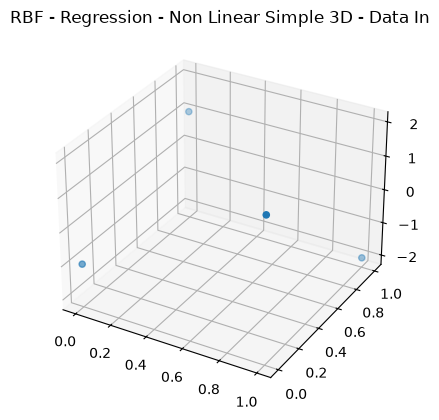

<Figure size 640x480 with 0 Axes>

In [ ]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      [2],
      [1],
      [-2],
      [-1]
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0],X[:,1],Y[:,0])

plt.title("RBF - Regression - Non Linear Simple 3D - Data In")
plt.show()
plt.clf()

#### Model

In [ ]:
nombre_de_centre = 4
model = RBF(nb_centres=nombre_de_centre, gamma=.5)
mse = model.train(X, Y)
print(f"MSE finale : {mse:.6f}")

MSE finale : 0.000000


#### Plot

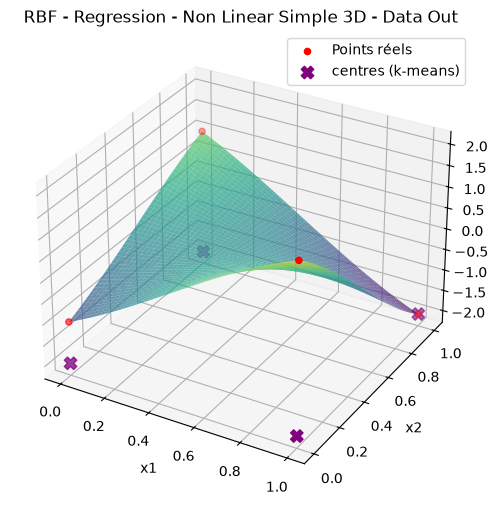

<Figure size 640x480 with 0 Axes>

In [ ]:
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict_scores(grid)[:, 0].reshape(xx.shape)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.7)

ax.scatter(X[:,0], X[:,1], Y[:,0], color='red', label='Points réels')

# centres du k-means
ax.scatter(model.centres[:,0], model.centres[:,1],
           np.full(len(model.centres), Z.min()),
           marker="X", c="purple", s=80, label='centres (k-means)')

ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("y")
ax.legend()

plt.title("RBF - Regression - Non Linear Simple 3D - Data Out")
plt.show()
plt.clf()